# Part 3: Advanced Text Processing – LDA and BERTopic Topic Modeling
Resources:

LDA:
- https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06
- https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
- https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/

BERTopic:
- https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly
- https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html

## Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import spacy
from spacy import displacy

from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer

import pyLDAvis
import pyLDAvis.gensim_models

import os

nlp = spacy.load("en_core_web_sm")

## Dataset

In [53]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


## 3.1 LDA 

In this section I:
- Train an LDA model on the State of the Union speeches
- Inspect the learned topics and the topic distribution for the first speech
- Train a BERTopic model
- Inspect BERTopic topics and visualize the topic distribution for the first speech

In [54]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [55]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

Code: dictionary, corpus, and LDA model

In [56]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
processed_docs_list = processed_docs.tolist()
id2word = Dictionary(processed_docs_list)
id2word.filter_extremes(no_below=5, no_above=0.5, keep_n=None)
corpus = [id2word.doc2bow(doc) for doc in processed_docs_list]

# train LDA model with 18 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=18,
    random_state=42,
    passes=10
)

Code: top 10 words for each topic

In [57]:
# print the top 10 words for each topic

print("--- LDA Topics ---")
for topic_id in range(18):
    words = lda_model.show_topic(topic_id, topn=10)
    words_str = " + ".join([f'{prob:.3f}*"{term}"' for term, prob in words])
    print(f"Topic: {topic_id}")
    print(f"Words: {words_str}\n")

--- LDA Topics ---
Topic: 0
Words: 0.004*"cent" + 0.004*"june" + 0.004*"gold" + 0.003*"island" + 0.003*"silver" + 0.003*"bond" + 0.003*"method" + 0.003*"convention" + 0.003*"indian" + 0.003*"note"

Topic: 1
Words: 0.008*"depression" + 0.007*"program" + 0.007*"recovery" + 0.006*"budget" + 0.006*"unemployment" + 0.006*"loan" + 0.006*"activity" + 0.006*"farm" + 0.005*"emergency" + 0.005*"cent"

Topic: 2
Words: 0.008*"dictator" + 0.005*"expression" + 0.004*"british" + 0.004*"1914" + 0.003*"impressive" + 0.003*"actual" + 0.003*"revolution" + 0.003*"schedule" + 0.003*"continent" + 0.003*"partisanship"

Topic: 3
Words: 0.008*"forest" + 0.007*"corporation" + 0.005*"judge" + 0.005*"wrong" + 0.005*"interstate" + 0.004*"employee" + 0.003*"bureau" + 0.003*"body" + 0.003*"mountain" + 0.003*"island"

Topic: 4
Words: 0.017*"program" + 0.014*"soviet" + 0.009*"1980" + 0.009*"u.s." + 0.008*"area" + 0.007*"major" + 0.006*"goal" + 0.006*"commitment" + 0.006*"challenge" + 0.006*"nuclear"

Topic: 5
Words: 0

Code: topic distribution for the first speech

In [58]:
# print the topic distribution for the first speech

first_doc_topics = lda_model.get_document_topics(corpus[0])
first_doc_topics

[(11, np.float32(0.99942815))]

Code: LDA visualization with pyLDAvis

In [59]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(
    lda_model,
    corpus,
    id2word
)
save_path = "outputs/lda_vis.html"
pyLDAvis.save_html(lda_vis, save_path)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.124490 -0.021460       1        1  25.619796
6     -0.177721  0.042077       2        1  19.981033
5      0.215260  0.071386       3        1   9.901162
7      0.135347 -0.070053       4        1   9.756259
8     -0.048065 -0.119211       5        1   7.285937
17    -0.174387  0.056450       6        1   5.735792
13    -0.173280  0.057692       7        1   5.117080
9     -0.065566 -0.065617       8        1   3.673824
11     0.221114  0.096518       9        1   3.313084
12     0.108985 -0.107040      10        1   3.208181
4      0.170987 -0.059934      11        1   2.417549
3     -0.048335 -0.061174      12        1   1.964508
1      0.001805 -0.137938      13        1   1.024306
14     0.149811  0.117592      14        1   0.773046
15    -0.097709  0.071397      15        1   0.174831
2     -0.030759  0.033480      16        1   0.045779
10    -0.027617  0.048256      17        1   0.003916
16    -0.035383  0.047579      18        1   0.003916, topic_info=           Term         Freq        Total Category  logprob  loglift
509     program  1272.000000  1272.000000  Default  30.0000  30.0000
978      mexico   852.000000   852.000000  Default  29.0000  29.0000
31    americans   990.000000   990.000000  Default  28.0000  28.0000
5330    article   492.000000   492.000000  Default  27.0000  27.0000
666     tonight   667.000000   667.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
3221     method     0.007818   526.093971  Topic18  -7.4658  -0.9690
664       today     0.007947   576.861497  Topic18  -7.4494  -1.0447
1148    appoint     0.007382   419.003878  Topic18  -7.5231  -0.7987
31    americans     0.008294   990.579258  Topic18  -7.4067  -1.5427
2624       cent     0.007440   614.048075  Topic18  -7.5154  -1.1731

[1282 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
4847      4  0.881688  --the
4847      8  0.080153  --the
3170      1  0.132787   11th
3170      2  0.079672   11th
3170      6  0.292131   11th
...     ...       ...    ...
744       9  0.116606  young
744      10  0.003239  young
744      11  0.016195  young
744      12  0.009717  young
744      14  0.009717  young

[5615 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 6, 8, 9, 18, 14, 10, 12, 13, 5, 4, 2, 15, 16, 3, 11, 17])

## 3.2 BERTopic modeling

Next, I fit a BERTopic model with a minimum topic size of 3, remove
stopwords from the topic representations using a `CountVectorizer`, and inspect
the topics and their probabilities for the first speech.

Code: BERTopic fit and stopword cleanup

In [60]:
docs = sou['Text'].to_list()

# train the model - this takes about 30 seconds
# remove stop words from the topics

topic_model = BERTopic(
    min_topic_size=3,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

vectorizer_model = CountVectorizer(stop_words="english")
topic_model.update_topics(
    docs,
    vectorizer_model=vectorizer_model
)

2025-11-21 07:28:41,072 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:21<00:00,  2.69s/it]
2025-11-21 07:29:04,011 - BERTopic - Embedding - Completed ✓
2025-11-21 07:29:04,012 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 07:29:06,218 - BERTopic - Dimensionality - Completed ✓
2025-11-21 07:29:06,220 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 07:29:06,241 - BERTopic - Cluster - Completed ✓
2025-11-21 07:29:06,245 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 07:29:07,818 - BERTopic - Representation - Completed ✓


Code: topic info table

In [61]:
# output the top 10 words for each topic
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,62,-1_states_government_united_congress,"[states, government, united, congress, public,...",[\nTo the Congress of the United States:\nYour...
1,0,38,0_america_new_people_americans,"[america, new, people, americans, american, ye...","[\nPlease, everybody, have a seat. Mr. Speaker..."
2,1,26,1_world_people_years_new,"[world, people, years, new, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
3,2,18,2_government_states_united_congress,"[government, states, united, congress, departm...",[\nTo the Senate and House of Representatives ...
4,3,11,3_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...","[\nMr. President, Mr. Speaker, Members of the ..."
5,4,10,4_government_work_congress_public,"[government, work, congress, public, great, co...",[\nTo the Senate and House of Representatives:...
6,5,10,5_states_united_public_government,"[states, united, public, government, congress,...",[\nFellow-Citizens of the Senate and House of ...
7,6,8,6_states_congress_united_year,"[states, congress, united, year, treaty, gover...",[\nFellow-Citizens of the Senate and House of ...
8,7,8,7_government_states_law_united,"[government, states, law, united, gold, congre...",[\nTo the Senate and House of Representatives:...
9,8,5,8_national_federal_reduction_public,"[national, federal, reduction, public, ought, ...",[\n[ As delivered in person before a joint ses...


Code: topic probability distribution for the first speech

100%|██████████| 1/1 [00:15<00:00, 15.88s/it]


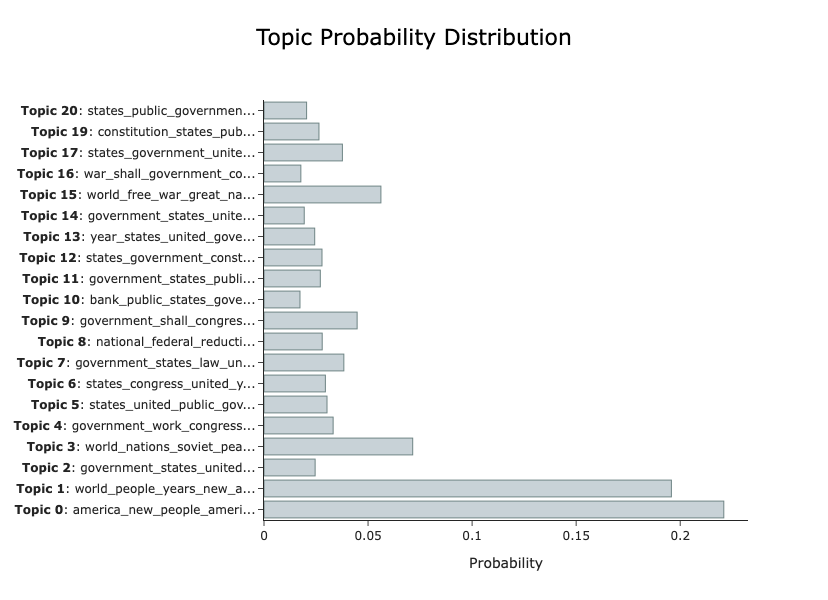

In [72]:
# output the topic distribution for the first speech
topic_distr, _ = topic_model.approximate_distribution(docs)
first_distribution = topic_distr[0] 
fig = topic_model.visualize_distribution(first_distribution,
                                         title="Topic Probability Distribution")

fig.write_html("outputs/topic_probability_distribution.html")
fig.show()

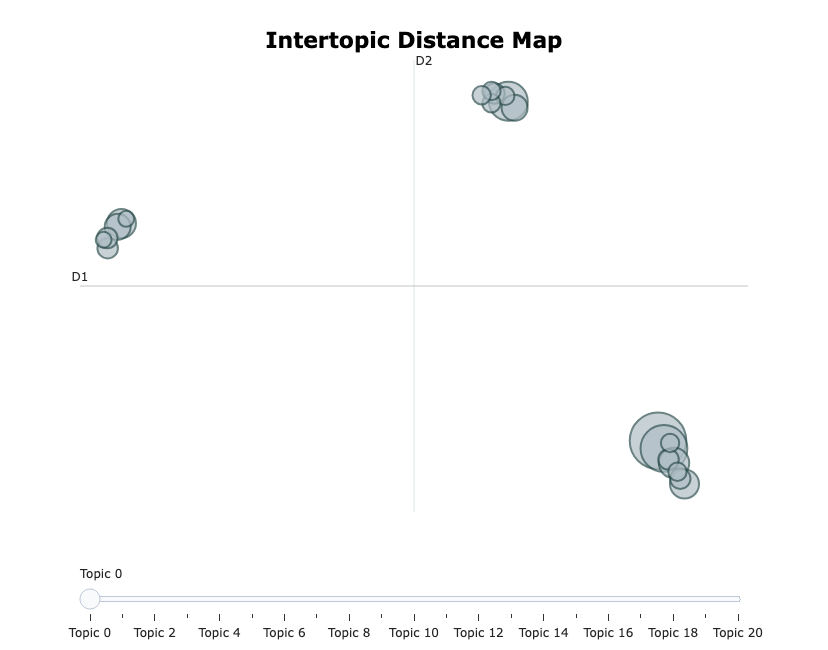

In [76]:
# run this cell to visualize the topics
topic_model.visualize_topics().write_html("outputs/intertopic_map.html")
topic_model.visualize_topics()